<a href="https://colab.research.google.com/github/NazmulHudaNabil/AIEngineeringBatch5/blob/main/CNN_Projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [7]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("higgstachyon/kannada-mnist")
# import os
# import pandas as pd

path = "/kaggle/input/kannada-mnist"

for root, dirs, files in os.walk(path):
    print(root, files)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kannada-mnist' dataset.
/kaggle/input/kannada-mnist ['.nfs00000000296067cd00000059']
/kaggle/input/kannada-mnist/Kannada_MNIST_datataset_paper ['kannada_mnist_arxiv_submission.pdf']
/kaggle/input/kannada-mnist/Kannada_MNIST_datataset_paper/Kannada_MNIST_Ubyte_gz []
/kaggle/input/kannada-mnist/Kannada_MNIST_datataset_paper/Kannada_MNIST_Ubyte_gz/Dig_MNIST []
/kaggle/input/kannada-mnist/Kannada_MNIST_datataset_paper/Kannada_MNIST_Ubyte_gz/Dig_MNIST/X_dig_MNIST-idx3-ubyte ['\x08\x03  (    \x1c   \x1c']
/kaggle/input/kannada-mnist/Kannada_MNIST_datataset_paper/Kannada_MNIST_Ubyte_gz/Dig_MNIST/y_dig_MNIST-idx1-ubyte ['y_dig_MNIST-idx1-ubyte']
/kaggle/input/kannada-mnist/Kannada_MNIST_datataset_paper/Kannada_MNIST_Ubyte_gz/Kannada_MNIST []
/kaggle/input/kannada-mnist/Kannada_MNIST_datataset_paper/Kannada_MNIST_Ubyte_gz/Kannada_MNIST/X_kannada_MNIST_train-idx3-ubyte ['▀                      -\xa0╥   \xa0                     \xa0╞    \xa0            

In [8]:

kannada_mnist_npz_path = os.path.join(path, 'Kannada_MNIST_datataset_paper', 'Kannada_MNIST_npz', 'Kannada_MNIST')

X_train = np.load(os.path.join(kannada_mnist_npz_path, 'X_kannada_MNIST_train.npz'))['arr_0']
y_train = np.load(os.path.join(kannada_mnist_npz_path, 'y_kannada_MNIST_train.npz'))['arr_0']
X_test = np.load(os.path.join(kannada_mnist_npz_path, 'X_kannada_MNIST_test.npz'))['arr_0']
y_test = np.load(os.path.join(kannada_mnist_npz_path, 'y_kannada_MNIST_test.npz'))['arr_0']

print(f"Loaded X_train shape: {X_train.shape}")
print(f"Loaded y_train shape: {y_train.shape}")
print(f"Loaded X_test shape: {X_test.shape}")
print(f"Loaded y_test shape: {y_test.shape}")

Loaded X_train shape: (60000, 28, 28)
Loaded y_train shape: (60000,)
Loaded X_test shape: (10000, 28, 28)
Loaded y_test shape: (10000,)


In [9]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [10]:
y_train

array([0, 1, 2, ..., 7, 8, 9], dtype=uint8)

In [11]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
y_train_cat

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [12]:
percepton = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation="softmax")
])

In [13]:
percepton.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["Accuracy"])

In [14]:
history_percp = percepton.fit(X_train, y_train_cat, epochs=5, batch_size=16, validation_data=(X_test, y_test_cat), verbose=1)

Epoch 1/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - Accuracy: 0.9240 - loss: 102.3160 - val_Accuracy: 0.8782 - val_loss: 201.2881
Epoch 2/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - Accuracy: 0.9444 - loss: 80.5834 - val_Accuracy: 0.8820 - val_loss: 238.5860
Epoch 3/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - Accuracy: 0.9492 - loss: 77.2425 - val_Accuracy: 0.8660 - val_loss: 292.5626
Epoch 4/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - Accuracy: 0.9507 - loss: 74.7843 - val_Accuracy: 0.8725 - val_loss: 284.7686
Epoch 5/5
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - Accuracy: 0.9532 - loss: 71.5347 - val_Accuracy: 0.8846 - val_loss: 249.7002


In [15]:
percepton_acc = percepton.evaluate(X_test, y_test_cat, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.8846 - loss: 249.7003


### Now Use ANN

In [16]:
ann = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [17]:
ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["Accuracy"])

In [18]:
history_ann = ann.fit(X_train, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test, y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - Accuracy: 0.9279 - loss: 1.1120 - val_Accuracy: 0.8754 - val_loss: 0.9889
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - Accuracy: 0.9636 - loss: 0.2100 - val_Accuracy: 0.8978 - val_loss: 0.8867
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - Accuracy: 0.9736 - loss: 0.1392 - val_Accuracy: 0.9130 - val_loss: 0.6129
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - Accuracy: 0.9775 - loss: 0.1022 - val_Accuracy: 0.9159 - val_loss: 0.6315
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - Accuracy: 0.9815 - loss: 0.0808 - val_Accuracy: 0.9123 - val_loss: 0.7021


In [19]:
ann_accuracy = ann.evaluate(X_test, y_test_cat, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9123 - loss: 0.7021


### Now, We Will Use CNN

In [20]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [21]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [22]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [24]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9740 - loss: 0.0893 - val_accuracy: 0.9596 - val_loss: 0.1529
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9799 - loss: 0.0684 - val_accuracy: 0.9640 - val_loss: 0.1427
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9844 - loss: 0.0544 - val_accuracy: 0.9646 - val_loss: 0.1437
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9855 - loss: 0.0497 - val_accuracy: 0.9628 - val_loss: 0.1605
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9872 - loss: 0.0455 - val_accuracy: 0.9638 - val_loss: 0.1688


In [25]:
cnn_accuracy = cnn.evaluate(X_test_cnn, y_test_cat, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9638 - loss: 0.1688


In [35]:
def plot_training(history, title):
    # Determine the correct accuracy key (case-insensitive)
    acc_key = 'accuracy' if 'accuracy' in history.history else 'Accuracy'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_Accuracy'

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history[acc_key], label="Train")
    plt.plot(history.history[val_acc_key], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

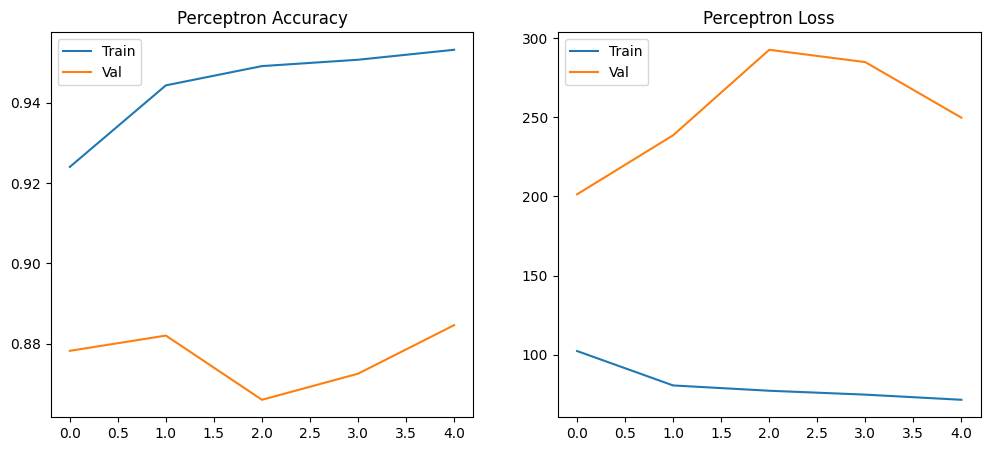

In [36]:
plot_training(history_percp, "Perceptron")

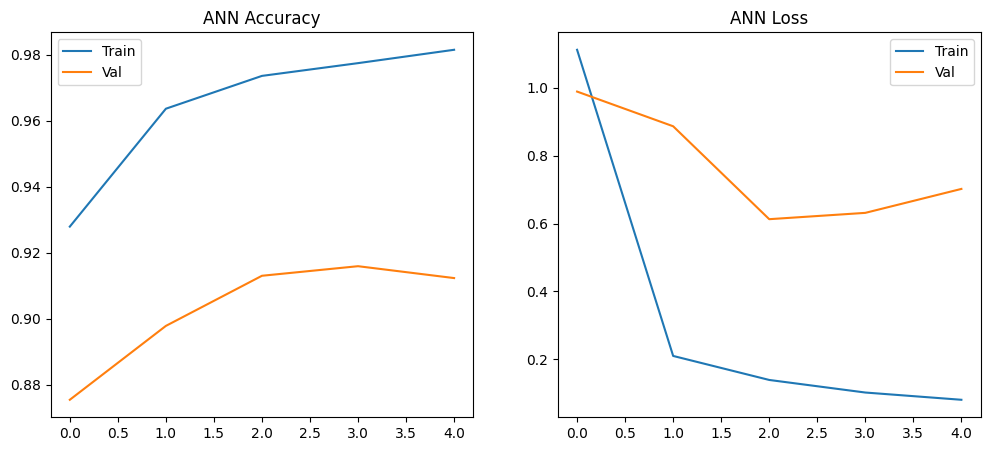

In [37]:
plot_training(history_ann, "ANN")

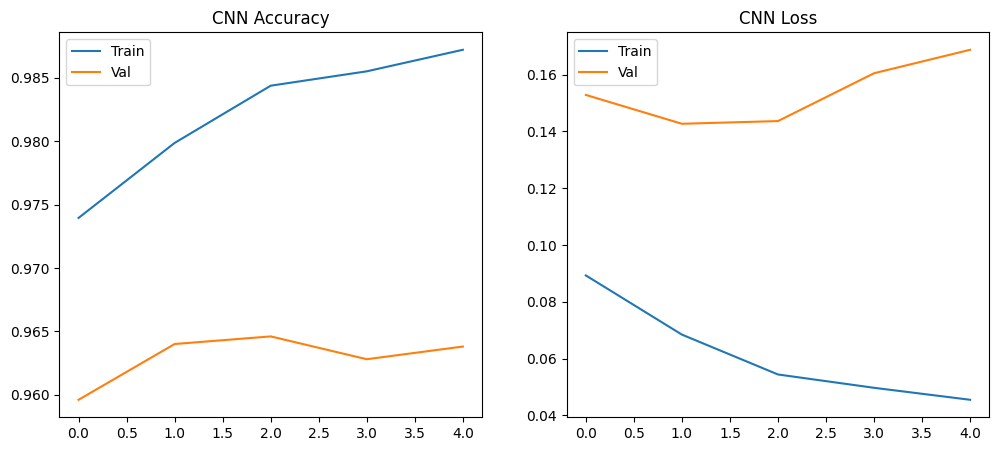

In [38]:
plot_training(history_cnn, "CNN")

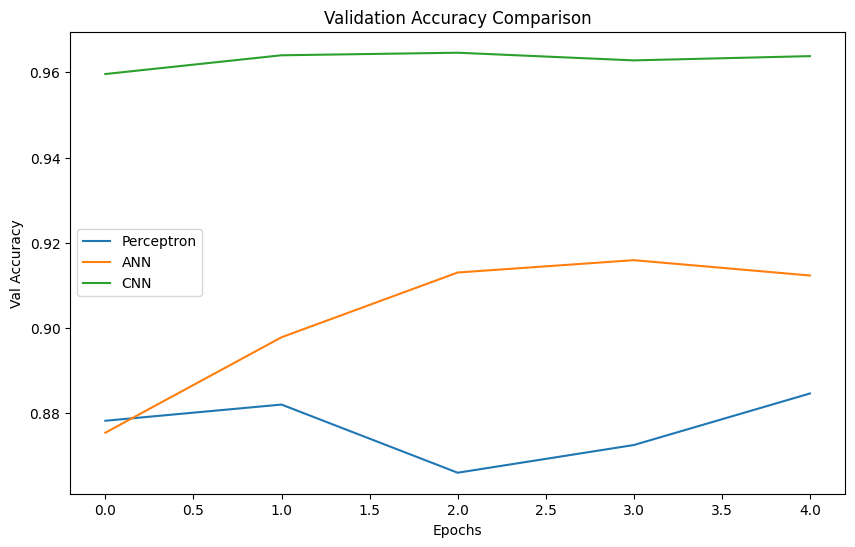

In [40]:
plt.figure(figsize=(10,6))

def get_val_accuracy_key(history):
    if 'val_accuracy' in history.history:
        return 'val_accuracy'
    elif 'val_Accuracy' in history.history:
        return 'val_Accuracy'
    return None

percp_val_acc_key = get_val_accuracy_key(history_percp)
ann_val_acc_key = get_val_accuracy_key(history_ann)
cnn_val_acc_key = get_val_accuracy_key(history_cnn)

if percp_val_acc_key:
    plt.plot(history_percp.history[percp_val_acc_key], label="Perceptron")
if ann_val_acc_key:
    plt.plot(history_ann.history[ann_val_acc_key], label="ANN")
if cnn_val_acc_key:
    plt.plot(history_cnn.history[cnn_val_acc_key], label="CNN")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [45]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


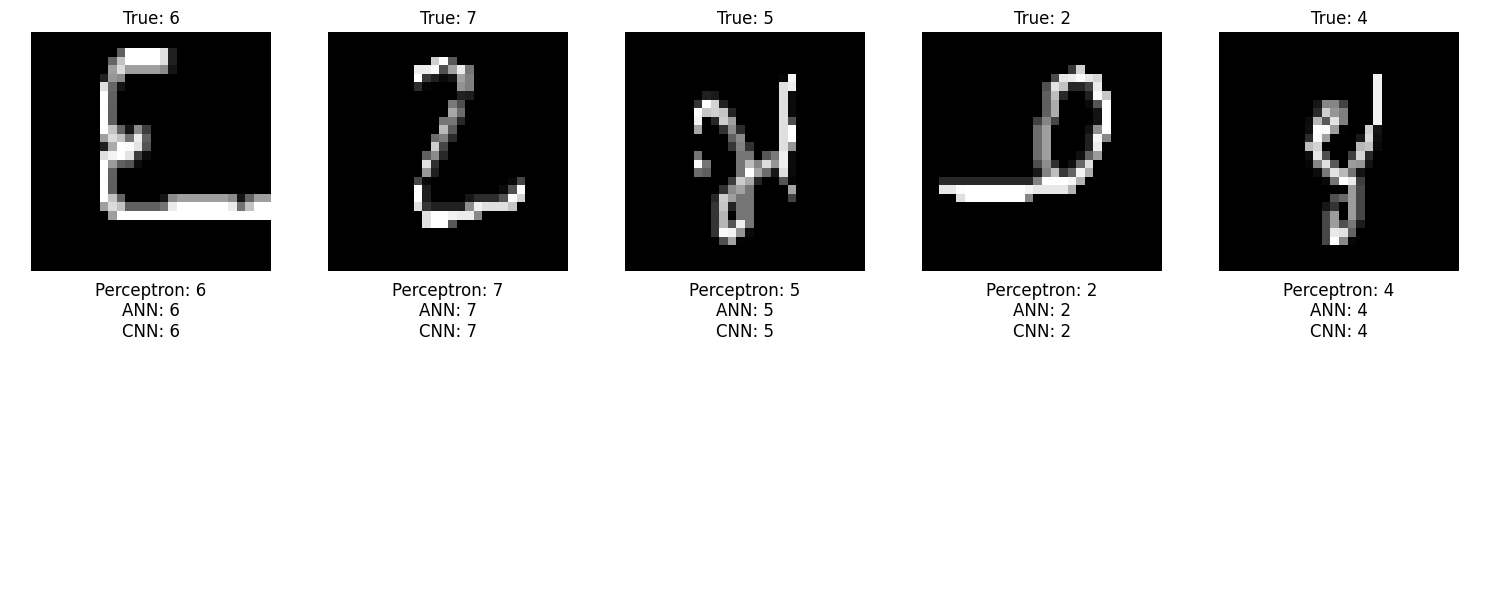

In [46]:
show_side_by_side([percepton, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test, X_test_cnn, y_test, 5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


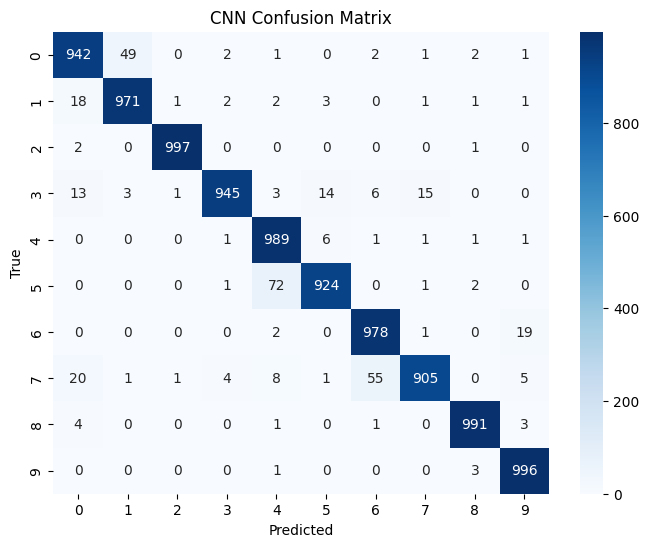

In [48]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

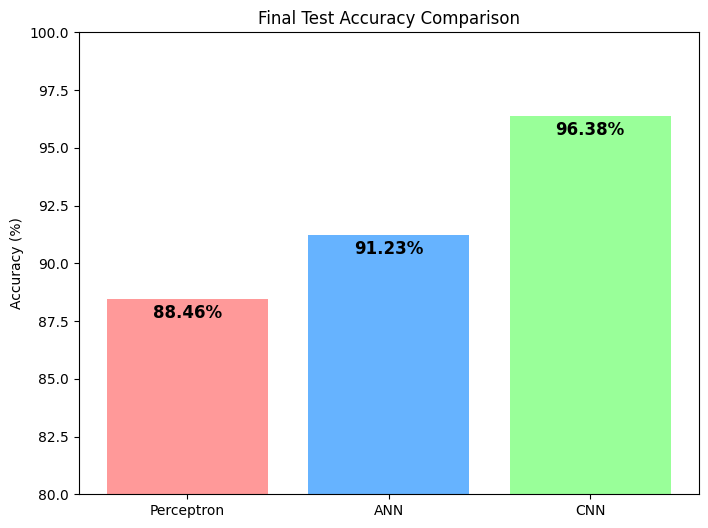

In [50]:
acc_percp = percepton_acc[1]
acc_ann = ann_accuracy[1]
acc_cnn = cnn_accuracy[1]

final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()